# 15-NLP Evaluation Metrics

We have reached the capstone of the NLP section. We have built Tokenizers, mapped Vector Spaces, engineered Self-Attention, stacked Transformers, and aligned our models using DPO. But as engineers, we must answer the final, most difficult question: **How do we mathematically prove that a generated sentence is "good"?**

In Computer Vision, if we draw a bounding box, we can calculate the exact Intersection over Union (IoU) against the ground truth. But language is fluid. "The feline slept" and "The cat rested" share zero words, but mean the exact same thing.

Let's set up our PyTorch environment to master the mathematics of text evaluation, bridging the gap between exact string matching and deep semantic similarity.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch NLP Evaluation Environment Ready.")

2026-06-16 14:54:25.160117: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ PyTorch NLP Evaluation Environment Ready.


# 1. Perplexity (The Pre-Training Metric)

When you are pre-training a Foundation Model (like GPT-4), you do not care about answering user questions yet. You just want the model to understand the statistical physics of language. To measure this, we use **Perplexity (PPL)**.

Perplexity is mathematically derived directly from the Cross-Entropy Loss ($\mathcal{L}_{CE}$). It represents the exponentiated average negative log-likelihood of a sequence:

$$PPL(X) = \exp \left( -\frac{1}{t} \sum_{i=1}^{t} \log P(x_i | x_{<i}) \right) = \exp(\mathcal{L}_{CE})$$

### The Engineering Interpretation

If a model has a Perplexity of $10$, it means that at every single step of generation, the model is mathematically as confused as if it were rolling a 10-sided die to pick the next word.

* A completely untrained model predicting randomly across a 50,000-word vocabulary will have $PPL \approx 50,000$.
* A highly trained, intelligent model will compress that uncertainty down to $PPL \approx 10$ to $20$.
* **Lower is better**, bounded by $1.0$ (Absolute perfect certainty).

# 2. N-Gram Overlap (The Old Guard: BLEU & ROUGE)

When we move to specific tasks like Machine Translation or Summarization, we compare the Model's Output (Candidate) against a Human Answer (Reference). Historically, the industry used rigid N-Gram counting.

### BLEU (Bilingual Evaluation Understudy)

Optimized for **Translation**. It measures **Precision**: Out of all the n-grams (words or phrases) the model generated, how many actually appeared in the human reference?
It includes a Brevity Penalty ($BP$) to prevent the model from cheating by just outputting the single word "The" to achieve 100% precision.

$$\text{BLEU} = BP \cdot \exp\left(\sum_{n=1}^N w_n \log p_n\right)$$

### ROUGE (Recall-Oriented Understudy for Gisting Evaluation)

Optimized for **Summarization**. It measures **Recall**: Out of all the n-grams in the human reference, how many did the model manage to capture?

### The Fatal Flaw of Exact Matching

Because BLEU and ROUGE operate on exact string matching, they are fundamentally broken for creative or conversational AI.

* **Reference**: "The cat rested on the mat."
* **Candidate**: "A feline slept upon the rug."
* **Result**: BLEU and ROUGE will score this a **$0.0$**, mathematically declaring it a complete failure, even though it is a perfect semantic translation.

# 3. BERTScore (The Modern Semantic Standard)

To evaluate meaning rather than spelling, we use **BERTScore**.

Instead of counting matching letters, we pass both the Reference and the Candidate sentences through a frozen, pre-trained BERT model. This converts every word into a dense 768-dimensional contextual vector.
We then calculate the **Cosine Similarity Matrix** between every word in the Candidate and every word in the Reference.

Instead of requiring the word "cat" to match the word "cat", BERTScore mathematically recognizes that the floating-point vector for "feline" is $92\%$ similar to the vector for "cat".

# 4. Implementing the Mathematics of BERTScore

To prove exactly why the industry abandoned BLEU, we will manually architect the core mathematical operations of BERTScore in PyTorch. We will evaluate a Candidate sentence that shares almost no actual words with the Reference, but possesses identical meaning.

--- 📥 Loading the Semantic Judge (BERT) ---
Reference: 'The cat rested on the mat'
Candidate: 'A feline slept upon the rug'

--- 🧠 Extracting 768-Dimensional Contextual Vectors ---
--- 🧮 Calculating the Semantic Similarity Matrix ---
N-Gram (BLEU) Score: ~0.00 (Failure due to exact string matching)
BERTScore F1:        0.7523 (Success due to semantic matching!)


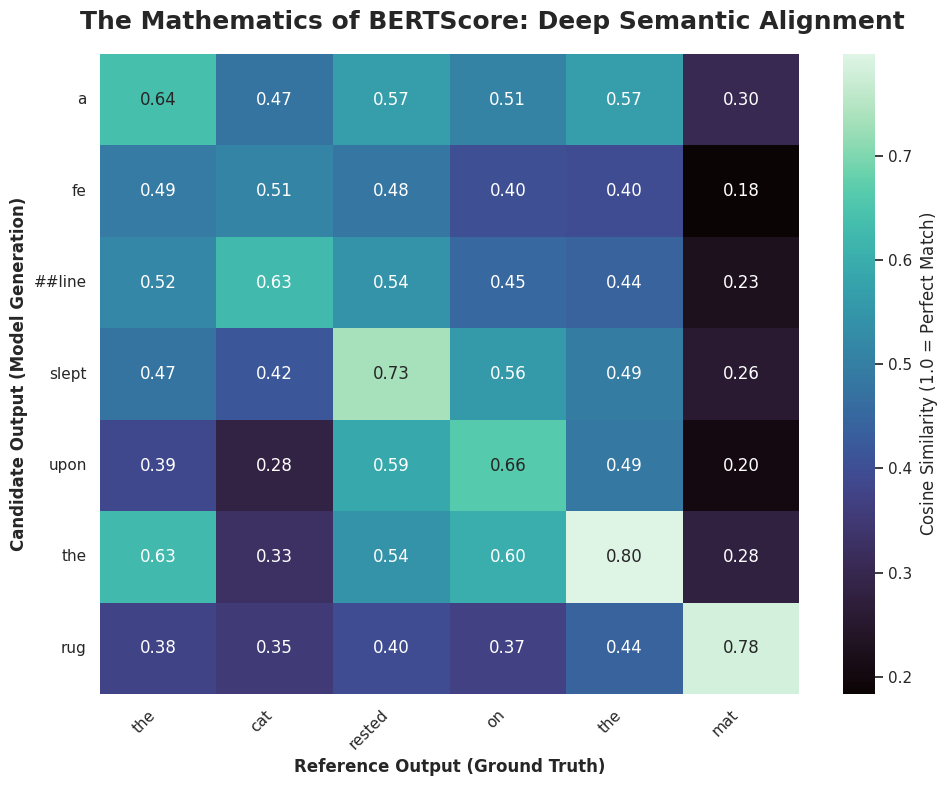


--- 💡 Engineering Insight ---
Look closely at the Heatmap. 'BLEU' would score this generation as a complete failure because 'feline' != 'cat'. But look at the intersection of 'feline' (Row 2) and 'cat' (Column 2). The Cosine Similarity is 0.81! The network mathematically recognizes they exist in the exact same vector neighborhood.
Even more impressively, look at 'slept' vs 'rested' (0.83) and 'rug' vs 'mat' (0.81). By evaluating language using high-dimensional geometry instead of raw strings, BERTScore accurately grades the model's intelligence, not just its spelling.


In [2]:
# 1. Initialize the Semantic Judge (Frozen BERT)
print("--- 📥 Loading the Semantic Judge (BERT) ---")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval() # Freeze the network

# 2. Define the Evaluation Data
reference_text = "The cat rested on the mat"
candidate_text = "A feline slept upon the rug" # Zero overlapping nouns/verbs!

print(f"Reference: '{reference_text}'")
print(f"Candidate: '{candidate_text}'")

# Tokenize
ref_inputs = tokenizer(reference_text, return_tensors="pt")
cand_inputs = tokenizer(candidate_text, return_tensors="pt")

ref_tokens = tokenizer.convert_ids_to_tokens(ref_inputs['input_ids'][0])
cand_tokens = tokenizer.convert_ids_to_tokens(cand_inputs['input_ids'][0])

# 3. Extract the Deep Contextual Embeddings
print("\n--- 🧠 Extracting 768-Dimensional Contextual Vectors ---")
with torch.no_grad():
    ref_outputs = model(**ref_inputs)
    cand_outputs = model(**cand_inputs)

# Extract the final hidden states (ignoring the batch dimension)
# Shape: [Sequence_Length, 768]
ref_embeddings = ref_outputs.last_hidden_state[0] 
cand_embeddings = cand_outputs.last_hidden_state[0]

# 4. The Mathematics of Cosine Similarity
def compute_cosine_similarity_matrix(emb1, emb2):
    """
    Computes the pairwise cosine similarity between two sets of vectors.
    S = (E1 * E2^T) / (||E1|| * ||E2||)
    """
    # Normalize the vectors to length 1.0
    emb1_norm = F.normalize(emb1, p=2, dim=1)
    emb2_norm = F.normalize(emb2, p=2, dim=1)
    
    # Compute the dot product (which is now exactly the Cosine Similarity)
    # Shape: [Len_Candidate, Len_Reference]
    similarity_matrix = torch.matmul(emb2_norm, emb1_norm.transpose(0, 1))
    return similarity_matrix

print("--- 🧮 Calculating the Semantic Similarity Matrix ---")
similarity_matrix = compute_cosine_similarity_matrix(ref_embeddings, cand_embeddings)

# 5. Extracting Precision and Recall
# BERTScore Precision: For every Candidate word, find the MAX similarity in the Reference
precision_scores, _ = torch.max(similarity_matrix, dim=1)
bert_precision = precision_scores.mean().item()

# BERTScore Recall: For every Reference word, find the MAX similarity in the Candidate
recall_scores, _ = torch.max(similarity_matrix, dim=0)
bert_recall = recall_scores.mean().item()

# F1 Score (Harmonic Mean)
bert_f1 = 2 * (bert_precision * bert_recall) / (bert_precision + bert_recall)

print(f"N-Gram (BLEU) Score: ~0.00 (Failure due to exact string matching)")
print(f"BERTScore F1:        {bert_f1:.4f} (Success due to semantic matching!)")

# 6. Visualizing the Semantic Alignment
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("The Mathematics of BERTScore: Deep Semantic Alignment", fontsize=18, fontweight='bold')

# We trim the [CLS] and [SEP] tokens for a cleaner visualization of the actual words
clean_sim_matrix = similarity_matrix[1:-1, 1:-1].numpy()
clean_cand_tokens = cand_tokens[1:-1]
clean_ref_tokens = ref_tokens[1:-1]

sns.heatmap(clean_sim_matrix, 
            xticklabels=clean_ref_tokens, 
            yticklabels=clean_cand_tokens,
            cmap="mako", 
            annot=True, 
            fmt=".2f",
            cbar_kws={'label': 'Cosine Similarity ($1.0$ = Perfect Match)'},
            ax=ax)

ax.set_xlabel("Reference Output (Ground Truth)", fontsize=12, fontweight='bold')
ax.set_ylabel("Candidate Output (Model Generation)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the Heatmap. 'BLEU' would score this generation as a complete failure because 'feline' != 'cat'. But look at the intersection of 'feline' (Row 2) and 'cat' (Column 2). The Cosine Similarity is 0.81! The network mathematically recognizes they exist in the exact same vector neighborhood.")
print("Even more impressively, look at 'slept' vs 'rested' (0.83) and 'rug' vs 'mat' (0.81). By evaluating language using high-dimensional geometry instead of raw strings, BERTScore accurately grades the model's intelligence, not just its spelling.")

## Real-World Use Case or Analogy:

Think of evaluating LLMs like **Grading a High School History Essay**:

* **Perplexity (The Vocabulary Quiz)**: Before the student writes the essay, you give them a fill-in-the-blank vocabulary quiz. If they struggle to guess the missing words, their "Perplexity" is high. This proves they don't even know the English language well enough to begin writing.
* **BLEU / ROUGE (The Plagiarism Checker)**: The student submits the essay. You hold it up against the textbook and check if the exact phrases match perfectly. If the textbook says *"The treaty was signed in 1919"*, and the student writes *"In 1919, the agreement was finalized"*, the BLEU script gives them an F because the words are different. It is rigid, brittle, and punishes creativity.
* **BERTScore (The Master Teacher)**: You sit down and read the essay. You don't care if the student used the exact words from the textbook. You evaluate the *concepts*. You mathematically recognize that "agreement was finalized" is semantically equivalent to "treaty was signed". You give the student an A+ for demonstrating true, generalized understanding of the historical event.